<a href="https://colab.research.google.com/github/ks-1019/RnT-Particle-Potentials/blob/main/rntclusterfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1358/3388948305.py:882: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  current = np.trapz(weight*B, s)
/tmp/ipykernel_1358/3388948305.py:884: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gradient = np.trapz(


Parameters: A_max = 50, step = 5, N_nu = 50
Current without optimisation = 0.002160757829897857
Gradient shape = (50,)
Gradient = [0.01378333 0.01666357 0.01275213 0.01002821 0.0081999  0.00691516
 0.00597038 0.00524906 0.00468141 0.00422359 0.0038468  0.00353143
 0.00326369 0.00303358 0.00283372 0.00265854 0.00250373 0.00236595
 0.00224252 0.00213132 0.00203061 0.00193897 0.00185521 0.00177835
 0.00170756 0.00164215 0.00158149 0.00152509 0.00147249 0.0014233
 0.00137718 0.00133382 0.00129295 0.00125434 0.00121775 0.00118299
 0.00114985 0.00111815 0.00108771 0.00105831 0.00102973 0.0010017
 0.00097385 0.00094566 0.00091628 0.00088421 0.0008463  0.00079478
 0.00070366 0.00041856]
Radius = {'radius_current': 4.898843585908654, 'radius_derivative': 4.1338840607306455, 'radius_used': 4.1338840607306455, 'inside_radius': True, 'radii_current': array([4.89884359]), 'radii_derivative': array([11.65400303,  5.01688834,  4.27483024,  4.13388406,  4.15513286,
        4.24666752,  4.39699614,  4.

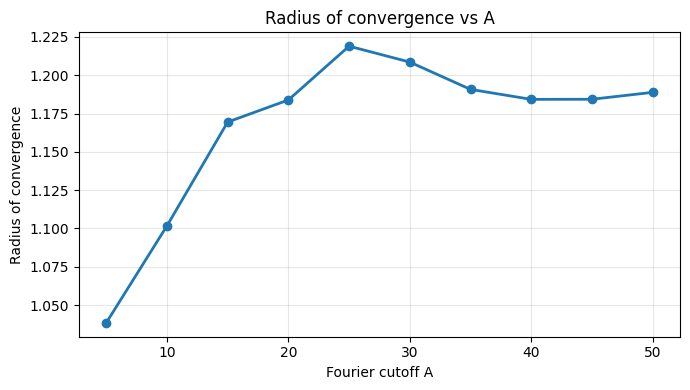


===== Modal continuation results =====

 stage  A    J_initial      J_final  improvement gradient_inf  iterations       radius  inside_radius                     status
     1  5 1.558321e-03 2.718003e-02 2.562171e-02    9.065e-07          75 1.038418e+00           True        objective tolerance
     2 10 2.718003e-02 3.231030e-02 5.130269e-03    5.833e-06         100 1.101694e+00           True maximum iterations reached
     3 15 3.231030e-02 3.417242e-02 1.862120e-03    9.020e-06         100 1.169431e+00           True maximum iterations reached
     4 20 3.417242e-02 3.514566e-02 9.732360e-04    1.093e-05         100 1.183827e+00           True maximum iterations reached
     5 25 3.514566e-02 3.575010e-02 6.044385e-04    1.172e-05         100 1.218921e+00           True maximum iterations reached
     6 30 3.575010e-02 3.616578e-02 4.156825e-04    1.193e-05         100 1.208534e+00           True maximum iterations reached
     7 35 3.616578e-02 3.647144e-02 3.056587e-04    1.16

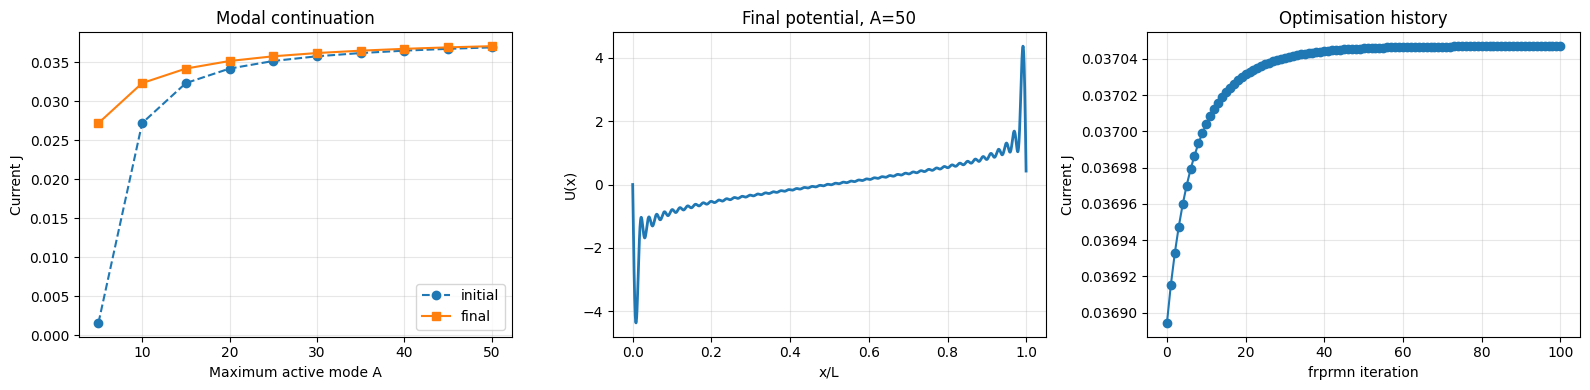

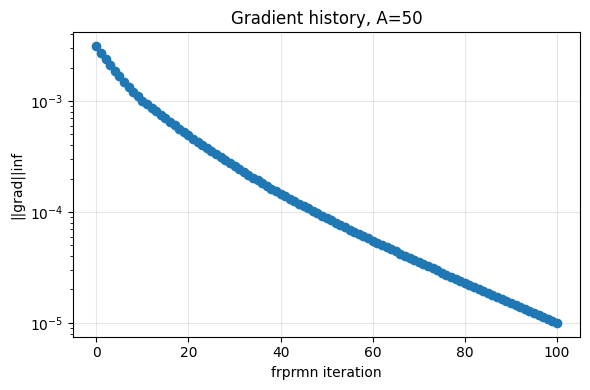

/tmp/ipykernel_1358/3388948305.py:882: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  current = np.trapz(weight*B, s)
/tmp/ipykernel_1358/3388948305.py:884: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gradient = np.trapz(



===== Perturbative-order diagnostic =====

 N_nu              J
    5 6.23070109e-02
   10 2.03523657e-02
   15 3.90362341e-02
   20 3.57178202e-02
   25 3.70096809e-02
   30 3.68540864e-02
   35 3.69222757e-02
   40 3.69175195e-02
   45 3.69205006e-02
   50 3.69205278e-02


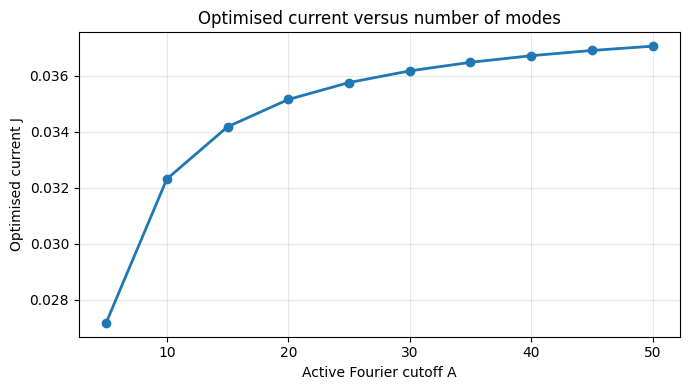

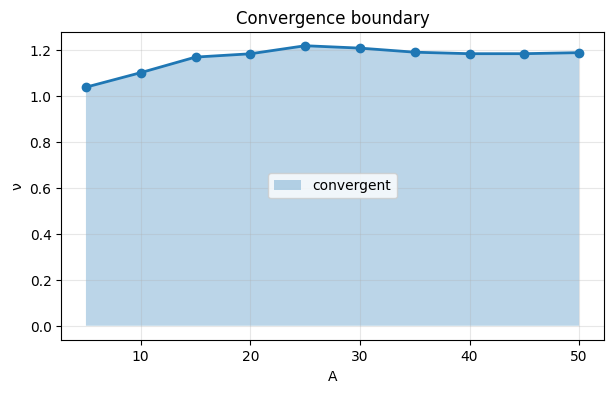

In [ ]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import fftconvolve
from scipy.special import gammainc
def initialise_modes(
    A,
    L=1.0,
    plot_initial=True,
):
    a_indices_full = np.arange(
        -A,
        A + 1,
    )

    U_base = np.zeros(
        2 * A + 1,
        dtype=np.complex128,
    )

    # initial sawtooth potential as was in the paper
    nonzero = a_indices_full != 0

    U_base[nonzero] = (
        1j * L**2
        / (
            2.0
            * np.pi
            * a_indices_full[nonzero]
        )
    )

    # plot the potential graph
    if plot_initial:
        x_vals = np.linspace(
            0.0,
            L,
            200,
        )

        U_vals = (
            np.sum(
                U_base[:, None]
                * np.exp(
                    1j
                    * 2.0
                    * np.pi
                    * a_indices_full[:, None]
                    * x_vals[None, :]
                    / L
                ),
                axis=0,
            )
            / L
        )

        plt.plot(
            x_vals,
            U_vals.real,
            label="Re(U)",
        )

    return a_indices_full, U_base
def U_modes(
    theta,
    U_base,
    A_k,
    a_indices_full,
    kind="imaginary",
):
    del U_base

    theta = np.asarray(
        theta,
        dtype=float,
    )

    a_indices_full = np.asarray(
        a_indices_full,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices_full,
        expected,
    ):
        raise ValueError(
            "a_indices_full must equal "
            "np.arange(-A_k,A_k+1)."
        )

    index = {
        int(a): i
        for i, a in enumerate(a_indices_full)
    }

    U_active = np.zeros(
        2 * A_k + 1,
        dtype=np.complex128,
    )

    if kind == "imaginary":
        if len(theta) != A_k:
            raise ValueError(
                f"Expected {A_k} parameters, "
                f"received {len(theta)}."
            )

        for a in range(1, A_k + 1):
            value = 1j * theta[a - 1]

            U_active[index[a]] = value
            U_active[index[-a]] = np.conjugate(value)

    elif kind == "full":
        if len(theta) != 2 * A_k - 1:
            raise ValueError(
                f"Expected {2 * A_k - 1} parameters, "
                f"received {len(theta)}."
            )

        # U1 is purely imaginary.
        U_active[index[1]] = 1j * theta[0]
        U_active[index[-1]] = -1j * theta[0]

        # Real parts of U2,...,UA.
        for a in range(2, A_k + 1):
            p = a - 1

            U_active[index[a]] += theta[p]
            U_active[index[-a]] += theta[p]

        # Imaginary parts of U2,...,UA.
        for a in range(2, A_k + 1):
            p = A_k + a - 2

            U_active[index[a]] += 1j * theta[p]
            U_active[index[-a]] -= 1j * theta[p]

    else:
        raise ValueError(
            "kind must be 'imaginary' or 'full'."
        )

    return U_active

def derivative_modes_from_theta(
    theta,
    A_k,
    a_indices_full,
    kind="imaginary",
):
    theta = np.asarray(
        theta,
        dtype=float,
    )

    a_indices_full = np.asarray(
        a_indices_full,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices_full,
        expected,
    ):
        raise ValueError(
            "a_indices_full must equal "
            "np.arange(-A_k,A_k+1)."
        )

    index = {
        int(a): i
        for i, a in enumerate(a_indices_full)
    }

    U = np.zeros(
        2 * A_k + 1,
        dtype=np.complex128,
    )

    if kind == "imaginary":
        if len(theta) != A_k:
            raise ValueError(
                f"Expected {A_k} parameters, "
                f"received {len(theta)}."
            )

        dU = np.zeros(
            (A_k, 2 * A_k + 1),
            dtype=np.complex128,
        )

        for a in range(1, A_k + 1):
            p = a - 1

            U[index[a]] = 1j * theta[p]
            U[index[-a]] = -1j * theta[p]

            dU[p, index[a]] = 1j
            dU[p, index[-a]] = -1j

    elif kind == "full":
        if len(theta) != 2 * A_k - 1:
            raise ValueError(
                f"Expected {2 * A_k - 1} parameters, "
                f"received {len(theta)}."
            )

        dU = np.zeros(
            (2 * A_k - 1, 2 * A_k + 1),
            dtype=np.complex128,
        )

        U[index[1]] = 1j * theta[0]
        U[index[-1]] = -1j * theta[0]

        dU[0, index[1]] = 1j
        dU[0, index[-1]] = -1j

        for a in range(2, A_k + 1):
            p = a - 1

            U[index[a]] += theta[p]
            U[index[-a]] += theta[p]

            dU[p, index[a]] = 1.0
            dU[p, index[-a]] = 1.0

        for a in range(2, A_k + 1):
            p = A_k + a - 2

            U[index[a]] += 1j * theta[p]
            U[index[-a]] -= 1j * theta[p]

            dU[p, index[a]] = 1j
            dU[p, index[-a]] = -1j

    else:
        raise ValueError(
            "kind must be 'imaginary' or 'full'."
        )

    return U, dU

def initial_theta_from_base(
    U_base,
    a_indices_full,
    A_k,
    kind="imaginary",
):
    U_base = np.asarray(
        U_base,
        dtype=np.complex128,
    )

    a_indices_full = np.asarray(
        a_indices_full,
        dtype=int,
    )

    full_index = {
        int(a): i
        for i, a in enumerate(a_indices_full)
    }

    if kind == "imaginary":
        theta = np.zeros(
            A_k,
            dtype=float,
        )

        for a in range(1, A_k + 1):
            theta[a - 1] = U_base[full_index[a]].imag

        return theta

    if kind == "full":
        theta = np.zeros(
            2 * A_k - 1,
            dtype=float,
        )

        theta[0] = U_base[full_index[1]].imag

        for a in range(2, A_k + 1):
            theta[a - 1] = U_base[full_index[a]].real
            theta[A_k + a - 2] = U_base[full_index[a]].imag

        return theta

    raise ValueError(
        "kind must be 'imaginary' or 'full'."
    )
def pad_theta(
    theta_old,
    old_A,
    new_A,
    kind,
):
    old_indices = np.arange(
        -old_A,
        old_A + 1,
    )

    old_U = U_modes(
        theta=theta_old,
        U_base=None,
        A_k=old_A,
        a_indices_full=old_indices,
        kind=kind,
    )

    old_index = {
        int(a): i
        for i, a in enumerate(old_indices)
    }

    if kind == "imaginary":
        theta_new = np.zeros(
            new_A,
            dtype=float,
        )

        for a in range(1, old_A + 1):
            theta_new[a - 1] = old_U[old_index[a]].imag

        return theta_new

    if kind == "full":
        theta_new = np.zeros(
            2 * new_A - 1,
            dtype=float,
        )

        theta_new[0] = old_U[old_index[1]].imag

        for a in range(2, old_A + 1):
            theta_new[a - 1] = old_U[old_index[a]].real
            theta_new[new_A + a - 2] = old_U[old_index[a]].imag

        return theta_new

    raise ValueError(
        "kind must be 'imaginary' or 'full'."
    )
def check_radius_of_convergence(
    coeffs,
    nu=1.0,
):
    coeffs = np.asarray(
        coeffs,
        dtype=float,
    )

    odd = [
        m
        for m in range(3, len(coeffs), 2)
        if np.isfinite(coeffs[m])
        and abs(coeffs[m]) > 0.0
    ]

    if not odd:
        return {
            "radius_current": np.inf,
            "radius_derivative": np.inf,
            "radius_used": np.inf,
            "inside_radius": True,
            "radii_current": np.array([]),
            "radii_derivative": np.array([]),
        }

    largest = odd[-1]

    radius_current = (
        abs(float(coeffs[largest]))
        ** (-1.0 / largest)
    )

    radii_derivative = np.array(
        [
            abs(float(m * coeffs[m]))
            ** (-1.0 / (m - 1))
            for m in odd
        ],
        dtype=float,
    )

    radius_derivative = float(
        np.min(radii_derivative)
    )

    radius_used = min(
        radius_current,
        radius_derivative,
    )

    return {
        "radius_current": float(radius_current),
        "radius_derivative": radius_derivative,
        "radius_used": float(radius_used),
        "inside_radius": bool(
            abs(nu) < radius_used
        ),
        "radii_current": np.array(
            [radius_current],
            dtype=float,
        ),
        "radii_derivative": radii_derivative,
    }
def _convolve_rows(
    left,
    right,
):
    return fftconvolve(
        left,
        right,
        mode="full",
        axes=1,
    )
def _derivative_recurrence_step(
    rho,
    mom,
    drho,
    dmom,
    W,
    dW,
    c_hat,
    c_none,
    c_und,
    chunk_size=16,
):
    P = drho.shape[0]

    output_length = (
        drho.shape[1]
        + len(W)
        - 1
    )

    if len(c_hat) != output_length:
        raise ValueError(
            "c_hat length does not match "
            "the convolution output."
        )

    drho_next = np.empty(
        (P, output_length),
        dtype=np.complex128,
    )

    dmom_next = np.empty(
        (P, output_length),
        dtype=np.complex128,
    )

    for start in range(
        0,
        P,
        chunk_size,
    ):
        stop = min(
            start + chunk_size,
            P,
        )

        sl = slice(
            start,
            stop,
        )

        d_rho_w = (
            _convolve_rows(
                drho[sl],
                W[None, :],
            )
            + _convolve_rows(
                rho[None, :],
                dW[sl],
            )
        )

        d_mom_w = (
            _convolve_rows(
                dmom[sl],
                W[None, :],
            )
            + _convolve_rows(
                mom[None, :],
                dW[sl],
            )
        )

        drho_next[sl] = (
            c_hat[None, :] * d_mom_w
            - c_none[None, :] * d_rho_w
        )

        dmom_next[sl] = (
            c_hat[None, :] * d_rho_w
            - c_und[None, :] * d_mom_w
        )

    return (
        drho_next,
        dmom_next,
    )
def current_series_and_gradient(
    a_indices,
    U_modes,
    dU_dtheta,
    A_k,
    D,
    w,
    L,
    gamma,
    N_nu,
    nu,
    return_coeffs=False,
    return_details=False,
):
    a_indices = np.asarray(
        a_indices,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices,
        expected,
    ):
        raise ValueError(
            "a_indices must equal "
            "np.arange(-A_k,A_k+1)."
        )

    U_modes = np.asarray(
        U_modes,
        dtype=np.complex128,
    )

    dU_dtheta = np.asarray(
        dU_dtheta,
        dtype=np.complex128,
    )

    N_modes = 2 * A_k + 1
    P = dU_dtheta.shape[0]

    if U_modes.shape != (N_modes,):
        raise ValueError(
            "U_modes has the wrong shape."
        )

    if dU_dtheta.shape != (
        P,
        N_modes,
    ):
        raise ValueError(
            "dU_dtheta has the wrong shape."
        )

    k_potential = (
        2.0
        * np.pi
        * a_indices
        / L
    )

    W = (
        k_potential
        * U_modes
        / L
    )

    dW = (
        dU_dtheta
        * k_potential[None, :]
        / L
    )

    U_minus = U_modes[::-1]
    dU_minus = dU_dtheta[:, ::-1]
    prefactor = 1j * k_potential

    rho = np.array(
        [1.0 + 0.0j],
    )

    mom = np.array(
        [0.0 + 0.0j],
    )

    drho = np.zeros(
        (P, 1),
        dtype=np.complex128,
    )

    dmom = np.zeros(
        (P, 1),
        dtype=np.complex128,
    )

    terms = np.zeros(
        N_nu + 1,
        dtype=float,
    )

    gradient_terms = np.zeros(
        (N_nu + 1, P),
        dtype=float,
    )

    for recurrence_order in range(
        1,
        N_nu,
    ):
        support = recurrence_order * A_k

        output_modes = np.arange(
            -support,
            support + 1,
        )

        k = (
            2.0
            * np.pi
            * output_modes
            / L
        )

        denominator = (
            D * D * k * k
            + w * w
            + 2.0 * gamma * D
        )

        c_hat = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        c_none = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        c_und = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        nonzero = output_modes != 0

        c_hat[nonzero] = (
            1j
            * w
            / denominator[nonzero]
        )

        c_none[nonzero] = (
            D * k[nonzero]**2
            + 2.0 * gamma
        ) / (
            k[nonzero]
            * denominator[nonzero]
        )

        c_und[nonzero] = (
            D
            * k[nonzero]
            / denominator[nonzero]
        )

        rho_w = np.convolve(
            rho,
            W,
        )

        mom_w = np.convolve(
            mom,
            W,
        )

        rho_next = (
            c_hat * mom_w
            - c_none * rho_w
        )

        mom_next = (
            c_hat * rho_w
            - c_und * mom_w
        )

        drho_next, dmom_next = (
            _derivative_recurrence_step(
                rho=rho,
                mom=mom,
                drho=drho,
                dmom=dmom,
                W=W,
                dW=dW,
                c_hat=c_hat,
                c_none=c_none,
                c_und=c_und,
            )
        )

        offset = support

        rho_slice = rho_next[
            offset - A_k:
            offset + A_k + 1
        ]

        drho_slice = drho_next[
            :,
            offset - A_k:
            offset + A_k + 1
        ]

        current_order = recurrence_order + 1

        terms[current_order] = (
            np.sum(
                prefactor
                * U_minus
                * rho_slice
            ).real
            / (L * L)
        )

        gradient_terms[current_order] = (
            np.sum(
                prefactor[None, :]
                * (
                    dU_minus
                    * rho_slice[None, :]
                    + U_minus[None, :]
                    * drho_slice
                ),
                axis=1,
            ).real
            / (L * L)
        )

        rho = rho_next
        mom = mom_next
        drho = drho_next
        dmom = dmom_next

    powers = nu ** np.arange(
        N_nu + 1,
    )

    odd_orders = np.arange(
        1,
        N_nu + 1,
        2,
    )
    # PICK METHOD OF RESUMMATION HERE
    resummation = "borel"
    if resummation == "series":
      current = float(
          np.sum(
              terms[odd_orders]
              * powers[odd_orders]
          )
      )
      gradient = np.sum(
          gradient_terms[odd_orders]
          * powers[odd_orders, None],
          axis=0,
      )
    elif resummation == "borel":
      current, gradient = borel_resum(
          terms=terms,
          gradient_terms=gradient_terms,
          nu=nu,
      )

    partials = np.zeros(
        N_nu + 1,
        dtype=float,
    )

    running = 0.0

    for n in range(
        N_nu + 1,
    ):
        if n % 2 == 1:
            running += (
                terms[n]
                * powers[n]
            )

        partials[n] = running

    radius_info = (
        check_radius_of_convergence(
            coeffs=terms,
            nu=nu,
        )
    )

    if return_details:
        return {
            "current": float(current),
            "gradient": np.asarray(
                gradient,
                dtype=float,
            ),
            "coeffs": terms,
            "gradient_coeffs": gradient_terms,
            "partials": partials,
            "radius": radius_info,
        }

    if return_coeffs:
        return (
            float(current),
            np.asarray(
                gradient,
                dtype=float,
            ),
            terms.copy(),
        )

    return (
        float(current),
        np.asarray(
            gradient,
            dtype=float,
        ),
    )
from scipy.special import factorial

def borel_resum(
    terms,
    gradient_terms,
    nu,
    cutoff=20.0,
    n_quad=200,
):
    s = np.linspace(0.0, cutoff, n_quad)

    B = np.zeros_like(s)
    dB = np.zeros(
        (len(s), gradient_terms.shape[1])
    )

    for n in range(len(terms)):
        coeff = terms[n] / factorial(n)

        B += coeff * (nu*s)**n

        dB += (
            gradient_terms[n]
            / factorial(n)
        )[None,:] * (nu*s)[:,None]**n

    weight = np.exp(-s)

    current = np.trapz(weight*B, s)

    gradient = np.trapz(
        weight[:,None]*dB,
        s,
        axis=0,
    )

    return current, gradient

def frprmn_maximise(
    theta0,
    J_and_grad,
    max_iter=100,
    gtol=1e-6,
    ftol=1e-10,
    initial_step=1e-2,
    beta_max=1.0,
    ascent_eta=1e-4,
    armijo_c1=1e-4,
    backtrack_factor=0.5,
    verbose=True,
):
    theta = np.asarray(
        theta0,
        dtype=float,
    ).copy()

    J, grad_J = J_and_grad(theta)

    J = float(J)
    grad_J = np.asarray(
        grad_J,
        dtype=float,
    )

    if not np.isfinite(J):
        raise ValueError(
            "Initial current is not finite."
        )

    if not np.all(
        np.isfinite(grad_J)
    ):
        raise ValueError(
            "Initial gradient contains NaN or inf."
        )

    direction = grad_J.copy()

    history = [
        {
            "iteration": 0,
            "J": J,
            "grad_norm": np.linalg.norm(
                grad_J,
                ord=np.inf,
            ),
            "alpha": 0.0,
            "beta": 0.0,
        }
    ]

    converged = False
    stopped_reason = (
        "maximum iterations reached"
    )

    for iteration in range(
        1,
        max_iter + 1,
    ):
        grad_norm = np.linalg.norm(
            grad_J,
            ord=np.inf,
        )

        if grad_norm < gtol:
            converged = True
            stopped_reason = (
                "gradient tolerance"
            )
            break

        slope = float(
            np.dot(
                grad_J,
                direction,
            )
        )

        if slope <= (
            ascent_eta
            * np.dot(
                grad_J,
                grad_J,
            )
        ):
            direction = grad_J.copy()

            slope = float(
                np.dot(
                    grad_J,
                    direction,
                )
            )

        alpha = min(initial_step, 0.2 / max(np.linalg.norm(direction), 1e-12))
        accepted = False

        for _ in range(30):
            theta_trial = (
                theta
                + alpha * direction
            )

            J_trial, grad_trial = (
                J_and_grad(
                    theta_trial,
                )
            )

            if (
                np.isfinite(J_trial)
                and np.all(
                    np.isfinite(grad_trial)
                )
                and J_trial
                >= J
                + armijo_c1
                * alpha
                * slope
            ):
                accepted = True
                break

            alpha *= backtrack_factor

        if not accepted:
            stopped_reason = (
                "Armijo line-search failure"
            )
            break

        theta_new = (
            theta
            + alpha * direction
        )

        J_new, grad_new = (
            J_and_grad(theta_new)
        )

        J_new = float(J_new)
        grad_new = np.asarray(
            grad_new,
            dtype=float,
        )

        if not np.isfinite(J_new):
            stopped_reason = (
                "non-finite current after update"
            )
            break

        if not np.all(
            np.isfinite(grad_new)
        ):
            stopped_reason = (
                "non-finite gradient after update"
            )
            break

        denominator = max(
            float(
                np.dot(
                    grad_J,
                    grad_J,
                )
            ),
            1e-30,
        )

        beta_pr = float(
            np.dot(
                grad_new,
                grad_new - grad_J,
            )
            / denominator
        )

        beta = min(
            beta_max,
            max(
                0.0,
                beta_pr,
            )
        )

        direction_new = (
            grad_new
            + beta * direction
        )

        if np.dot(
            grad_new,
            direction_new,
        ) <= (
            ascent_eta
            * np.dot(
                grad_new,
                grad_new,
            )
        ):
            direction_new = grad_new.copy()
            beta = 0.0

        relative_change = (
            abs(J_new - J)
            / max(
                1.0,
                abs(J),
            )
        )

        history.append(
            {
                "iteration": iteration,
                "J": J_new,
                "grad_norm": np.linalg.norm(
                    grad_new,
                    ord=np.inf,
                ),
                "alpha": alpha,
                "beta": beta,
            }
        )

        if verbose:
            print(
                f"frprmn iteration {iteration:3d}: "
                f"J={J_new:.12e}, "
                f"alpha={alpha:.4e}, "
                f"beta={beta:.4e}, "
                f"||grad||inf="
                f"{np.linalg.norm(grad_new, ord=np.inf):.4e}"
            )

        theta = theta_new
        J = J_new
        grad_J = grad_new
        direction = direction_new

        if (
          relative_change < ftol
          and np.linalg.norm(grad_new, ord=np.inf) < gtol
          ):
            converged = True
            stopped_reason = (
                "objective tolerance"
            )
            break

    info = {
        "converged": converged,
        "stopped_reason": stopped_reason,
        "history": history,
        "gradient_norm": np.linalg.norm(
            grad_J,
            ord=np.inf,
        ),
        "iterations": len(history) - 1,
    }

    return theta, J, info

def optimiser(
    A_max,
    step,
    L_domain,
    D_diff,
    w_freq,
    gamma_rtp,
    N_nu_val,
    nu_height,
    parameterization_kind="imaginary",
):
    a_indices_full, U_base = initialise_modes(
        A=A_max,
        L=L_domain,
        plot_initial=False,
    )

    n_stages = A_max // step
    theta_opt = None
    previous_A = None
    stage_results = []

    for k in range(n_stages):
        stage = k + 1
        A_k = (k + 1) * step

        a_indices_stage = np.arange(
            -A_k,
            A_k + 1,
        )

        if parameterization_kind == "imaginary":
            dim_k = A_k
        elif parameterization_kind == "full":
            dim_k = 2 * A_k - 1
        else:
            raise ValueError(
                "Invalid parameterization_kind."
            )

        if theta_opt is None:
            theta_init = initial_theta_from_base(
                U_base=U_base,
                a_indices_full=a_indices_full,
                A_k=A_k,
                kind=parameterization_kind,
            )
        else:
            theta_init = pad_theta(
                theta_old=theta_opt,
                old_A=previous_A,
                new_A=A_k,
                kind=parameterization_kind,
            )

        def J_and_grad(theta_vec):
            U_modes_now, dU_now = (
                derivative_modes_from_theta(
                    theta=theta_vec,
                    A_k=A_k,
                    a_indices_full=a_indices_stage,
                    kind=parameterization_kind,
                )
            )

            details = current_series_and_gradient(
                a_indices=a_indices_stage,
                U_modes=U_modes_now,
                dU_dtheta=dU_now,
                A_k=A_k,
                D=D_diff,
                w=w_freq,
                L=L_domain,
                gamma=gamma_rtp,
                N_nu=N_nu_val,
                nu=nu_height,
                return_details=True,
            )

            return (
                details["current"],
                details["gradient"],
            )

        J_initial, grad_initial = (
            J_and_grad(theta_init)
        )

        print(
            f"\nStarting stage "
            f"{stage}/{n_stages}"
        )

        print(
            f"A_k = {A_k}"
        )

        print(
            f"Number of parameters = {dim_k}"
        )

        print(
            f"Initial current = "
            f"{J_initial:.12e}"
        )

        print(
            "Initial gradient norm = "
            f"{np.linalg.norm(grad_initial, ord=np.inf):.6e}"
        )

        theta_candidate, J_candidate, info = (
            frprmn_maximise(
                theta0=theta_init,
                J_and_grad=J_and_grad,
                max_iter=100,
                gtol=1e-6,
                ftol=1e-10,
                initial_step=1.0,
                beta_max=1.0,
                ascent_eta=1e-4,
                armijo_c1=1e-4,
                verbose=True,
            )
        )

        U_candidate, dU_candidate = (
            derivative_modes_from_theta(
                theta=theta_candidate,
                A_k=A_k,
                a_indices_full=a_indices_stage,
                kind=parameterization_kind,
            )
        )

        candidate_details = current_series_and_gradient(
            a_indices=a_indices_stage,
            U_modes=U_candidate,
            dU_dtheta=dU_candidate,
            A_k=A_k,
            D=D_diff,
            w=w_freq,
            L=L_domain,
            gamma=gamma_rtp,
            N_nu=N_nu_val,
            nu=nu_height,
            return_details=True,
        )

        J_candidate = candidate_details["current"]
        coeffs_candidate = candidate_details["coeffs"]
        radius_info = candidate_details["radius"]

        improves = (
            J_candidate
            >= J_initial
        )

        finite_candidate = (
            np.isfinite(J_candidate)
            and np.all(
                np.isfinite(
                    coeffs_candidate
                )
            )
        )

        candidate_stable = (
            finite_candidate
            and improves
            and radius_info["inside_radius"]
        )

        if candidate_stable:
            theta_opt = theta_candidate.copy()
            J_best = J_candidate
            accepted = True
            status = "accepted"
        else:
            print(
                "Rejecting candidate: "
                f"J={J_candidate:.6e}, "
                f"radius="
                f"{radius_info['radius_used']:.6e}, "
                f"|nu|={abs(nu_height):.6e}, "
                f"inside_radius="
                f"{radius_info['inside_radius']}, "
                f"improves={improves}"
            )

            theta_opt = theta_init.copy()
            J_best = J_initial
            accepted = False
            status = (
                "rejected: outside radius "
                "or no improvement"
            )

        J_final, grad_final = J_and_grad(theta_opt)

        result = {
            "stage": stage,
            "A_k": A_k,
            "theta_initial": theta_init.copy(),
            "theta_opt": theta_opt.copy(),
            "J_initial": J_initial,
            "J_best": J_best,
            "J_final": J_final,
            "gradient_norm": np.linalg.norm(
                grad_final,
                ord=np.inf,
            ),
            "frprmn_info": info,
            "radius_current": radius_info[
                "radius_current"
            ],
            "radius_derivative": radius_info[
                "radius_derivative"
            ],
            "radius_used": radius_info[
                "radius_used"
            ],
            "inside_radius": radius_info[
                "inside_radius"
            ],
            "accepted": accepted,
            "status": status,
        }

        stage_results.append(result)

        print(
            f"Finished stage {stage}: "
            f"A_k={A_k}, "
            f"J_initial={J_initial:.12e}, "
            f"J_final={J_final:.12e}, "
            f"iterations={info['iterations']}, "
            f"reason={info['stopped_reason']}, "
            f"radius={radius_info['radius_used']:.6e}, "
            f"inside={radius_info['inside_radius']}, "
            f"status={status}"
        )

        previous_A = A_k

    return (
        theta_opt,
        a_indices_full,
        U_base,
        stage_results,
    )

# SIMULATION PARAMETERS
A_max = 50
step = 5

L_domain = 1.0
D_diff = 1.0
w_freq = 1.0
gamma_rtp = 1.0

N_nu_val = 50
nu_height = 1.0

# Use "full" for a low-mode audit.
# Use "imaginary" for the high-mode continuation.
parameterization_kind = "imaginary"

a_indices_full, U_base = initialise_modes(
    A=A_max,
    L=L_domain,
    plot_initial=False,
)

theta_initial = initial_theta_from_base(
    U_base=U_base,
    a_indices_full=a_indices_full,
    A_k=A_max,
    kind=parameterization_kind,
)

U_initial, dU_initial = (
    derivative_modes_from_theta(
        theta=theta_initial,
        A_k=A_max,
        a_indices_full=a_indices_full,
        kind=parameterization_kind,
    )
)

initial_details = current_series_and_gradient(
    a_indices=a_indices_full,
    U_modes=U_initial,
    dU_dtheta=dU_initial,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
    return_details=True,
)

print(
    f"Parameters: A_max = {A_max}, step = {step}, N_nu = {N_nu_val}"
)

print(
    "Current without optimisation =",
    initial_details["current"],
)

print(
    "Gradient shape =",
    initial_details["gradient"].shape,
)

print(
    "Gradient =",
    initial_details["gradient"],
)

print(
    "Radius =",
    initial_details["radius"],
)
coeffs = initial_details["coeffs"]

print("\nFirst perturbative coefficients:\n")

for n in range(
    min(12, len(coeffs)),
):
    print(
        f"J^({n}) = "
        f"{coeffs[n]: .12e}"
    )

even_orders = np.arange(
    0,
    len(coeffs),
    2,
)

odd_orders = np.arange(
    1,
    len(coeffs),
    2,
)

max_even = np.max(
    np.abs(
        coeffs[even_orders]
    )
)

max_odd = np.max(
    np.abs(
        coeffs[odd_orders]
    )
)

print(
    "\nMaximum even coefficient =",
    max_even,
)

print(
    "Maximum odd coefficient =",
    max_odd,
)

print(
    "Even/odd coefficient ratio =",
    max_even / max(
        max_odd,
        1e-30,
    ),
)
def finite_difference_gradient_check(
    theta,
    objective,
    epsilon=2e-6,
):
    theta = np.asarray(
        theta,
        dtype=float,
    )

    analytic = objective(theta)["gradient"]

    finite_difference = np.zeros_like(
        theta,
        dtype=float,
    )

    for p in range(len(theta)):
        theta_plus = theta.copy()
        theta_minus = theta.copy()

        theta_plus[p] += epsilon
        theta_minus[p] -= epsilon

        J_plus = objective(theta_plus)["current"]
        J_minus = objective(theta_minus)["current"]

        finite_difference[p] = (
            J_plus - J_minus
        ) / (2.0 * epsilon)

    difference = (
        analytic
        - finite_difference
    )

    relative_error = (
        np.linalg.norm(difference)
        / max(
            np.linalg.norm(
                finite_difference
            ),
            1e-14,
        )
    )

    return {
        "analytic": analytic,
        "finite_difference": finite_difference,
        "relative_error": relative_error,
        "max_absolute_error": np.max(
            np.abs(difference)
        ),
    }
A_audit = min(
    3,
    A_max,
)

a_indices_audit = np.arange(
    -A_audit,
    A_audit + 1,
)

theta_audit = initial_theta_from_base(
    U_base=U_base,
    a_indices_full=a_indices_full,
    A_k=A_audit,
    kind="full",
)


def audit_objective(theta):
    U_audit, dU_audit = (
        derivative_modes_from_theta(
            theta=theta,
            A_k=A_audit,
            a_indices_full=a_indices_audit,
            kind="full",
        )
    )

    details = current_series_and_gradient(
        a_indices=a_indices_audit,
        U_modes=U_audit,
        dU_dtheta=dU_audit,
        A_k=A_audit,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=min(N_nu_val, 15),
        nu=nu_height,
        return_details=True,
    )

    return {
        "current": details["current"],
        "gradient": details["gradient"],
    }
gradient_audit = finite_difference_gradient_check(
    theta=theta_audit,
    objective=audit_objective,
    epsilon=2e-6,
)

print(
    "\n===== Gradient audit ====="
)

print(
    "Relative gradient error =",
    gradient_audit["relative_error"],
)

print(
    "Maximum absolute gradient error =",
    gradient_audit["max_absolute_error"],
)

print(
    "Analytic gradient =",
    gradient_audit["analytic"],
)

print(
    "Finite-difference gradient =",
    gradient_audit["finite_difference"],
)
start = time.time()
theta_opt, a_indices_full, U_base, stage_results = (
    optimiser(
        A_max=A_max,
        step=step,
        L_domain=L_domain,
        D_diff=D_diff,
        w_freq=w_freq,
        gamma_rtp=gamma_rtp,
        N_nu_val=N_nu_val,
        nu_height=nu_height,
        parameterization_kind=parameterization_kind,
    )
)
print(
    "Elapsed:",
    time.time() - start,
    "seconds"
)
a_indices_final = np.arange(
    -A_max,
    A_max + 1,
)

U_opt, dU_opt = (
    derivative_modes_from_theta(
        theta=theta_opt,
        A_k=A_max,
        a_indices_full=a_indices_final,
        kind=parameterization_kind,
    )
)

final_details = current_series_and_gradient(
    a_indices=a_indices_final,
    U_modes=U_opt,
    dU_dtheta=dU_opt,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
    return_details=True,
)

print(
    "\n===== Final result ====="
)

print(
    "Final current =",
    final_details["current"],
)

print(
    "Final gradient norm =",
    np.linalg.norm(
        final_details["gradient"],
        ord=np.inf,
    ),
)

print(
    "Final radius =",
    final_details["radius"],
)
table_rows = []

for result in stage_results:
    info = result["frprmn_info"]

    table_rows.append(
        {
            "stage": result["stage"],
            "A": result["A_k"],
            "J_initial": result["J_initial"],
            "J_final": result["J_final"],
            "improvement": (
                result["J_final"]
                - result["J_initial"]
            ),
            "gradient_inf": result[
                "gradient_norm"
            ],
            "iterations": info[
                "iterations"
            ],
            "radius": result[
                "radius_used"
            ],
            "inside_radius": result[
                "inside_radius"
            ],
            "status": info[
                "stopped_reason"
            ],
        }
    )

results_table = pd.DataFrame(
    table_rows,
)

A_vals = np.array(
    [r["A_k"] for r in stage_results]
)

R_vals = np.array(
    [r["radius_used"] for r in stage_results]
)

plt.figure(figsize=(7,4))

plt.plot(
    A_vals,
    R_vals,
    "o-",
    linewidth=2,
)

plt.xlabel("Fourier cutoff A")
plt.ylabel("Radius of convergence")
plt.title("Radius of convergence vs A")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "\n===== Modal continuation results =====\n"
)

print(
    results_table.to_string(
        index=False,
        formatters={
            "J_initial": "{:.6e}".format,
            "J_final": "{:.6e}".format,
            "improvement": "{:.6e}".format,
            "gradient_inf": "{:.3e}".format,
            "radius": "{:.6e}".format,
        },
    )
)
x_plot = np.linspace(
    0.0,
    L_domain,
    2000,
    endpoint=False,
)

k_vals = (
    2.0
    * np.pi
    * a_indices_final
    / L_domain
)

U_opt_x = (
    np.sum(
        U_opt[:, None]
        * np.exp(
            1j
            * k_vals[:, None]
            * x_plot[None, :]
        ),
        axis=0,
    )
    / L_domain
)

print(U_opt)
final_info = stage_results[-1][
    "frprmn_info"
]

history = pd.DataFrame(
    final_info["history"]
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4),
)

axes[0].plot(
    results_table["A"],
    results_table["J_initial"],
    "o--",
    label="initial",
)

axes[0].plot(
    results_table["A"],
    results_table["J_final"],
    "s-",
    label="final",
)

axes[0].set_xlabel(
    "Maximum active mode A"
)

axes[0].set_ylabel(
    "Current J"
)

axes[0].set_title(
    "Modal continuation"
)

axes[0].grid(
    alpha=0.3,
)

axes[0].legend()

axes[1].plot(
    x_plot / L_domain,
    U_opt_x.real,
    linewidth=2.0,
)

axes[1].set_xlabel(
    "x/L"
)

axes[1].set_ylabel(
    "U(x)"
)

axes[1].set_title(
    f"Final potential, A={A_max}"
)

axes[1].grid(
    alpha=0.3,
)

axes[2].plot(
    history["iteration"],
    history["J"],
    "o-",
)

axes[2].set_xlabel(
    "frprmn iteration"
)

axes[2].set_ylabel(
    "Current J"
)

axes[2].set_title(
    "Optimisation history"
)

axes[2].grid(
    alpha=0.3,
)

fig.tight_layout()
plt.show()
plt.figure(
    figsize=(6, 4),
)

plt.semilogy(
    history["iteration"],
    history["grad_norm"],
    "o-",
)

plt.xlabel(
    "frprmn iteration"
)

plt.ylabel(
    "||grad||inf"
)

plt.title(
    f"Gradient history, A={A_max}"
)

plt.grid(
    alpha=0.3,
)

plt.tight_layout()
plt.show()
orders = [
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
    45,
    50
]

order_currents = []

for N_test in orders:
    test_details = current_series_and_gradient(
        a_indices=a_indices_final,
        U_modes=U_opt,
        dU_dtheta=dU_opt,
        A_k=A_max,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=N_test,
        nu=nu_height,
        return_details=True,
    )

    order_currents.append(
        test_details["partials"][N_test]
    )

order_table = pd.DataFrame(
    {
        "N_nu": orders,
        "J": order_currents,
    }
)

print(
    "\n===== Perturbative-order diagnostic =====\n"
)

print(
    order_table.to_string(
        index=False,
        formatters={
            "J": "{:.8e}".format,
        },
    )
)
A_values = np.array(
    [
        result["A_k"]
        for result in stage_results
    ]
)

J_values = np.array(
    [
        result["J_final"]
        for result in stage_results
    ]
)

plt.figure(
    figsize=(7, 4),
)

plt.plot(
    A_values,
    J_values,
    "o-",
    linewidth=2,
    markersize=6,
)

plt.xlabel(
    "Active Fourier cutoff A"
)

plt.ylabel(
    "Optimised current J"
)

plt.title(
    "Optimised current versus number of modes"
)

plt.grid(
    alpha=0.3,
)

plt.tight_layout()
plt.show()

A_vals = np.array(
    [r["A_k"] for r in stage_results]
)

R_vals = np.array(
    [r["radius_used"] for r in stage_results]
)

nu_grid = np.linspace(
    0,
    max(R_vals)*1.5,
    300,
)

phase = np.zeros(
    (len(nu_grid), len(A_vals))
)

for j,A in enumerate(A_vals):

    R = R_vals[j]

    phase[:,j] = (
        nu_grid < R
    )
plt.figure(figsize=(7,4))

plt.plot(
    A_vals,
    R_vals,
    "o-",
    linewidth=2,
)

plt.fill_between(
    A_vals,
    0,
    R_vals,
    alpha=0.3,
    label="convergent",
)

plt.xlabel("A")
plt.ylabel("ν")

plt.title(
    "Convergence boundary"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import fftconvolve
from scipy.special import gammainc
def initialise_modes(
    A,
    L=1.0,
    plot_initial=True,
):
    a_indices_full = np.arange(
        -A,
        A + 1,
    )

    U_base = np.zeros(
        2 * A + 1,
        dtype=np.complex128,
    )

    # optimal potential from A+50 (previous test 4.2)
    fifty = np.where(a_indices_full == 50)[0][0]
    minus_fifty = np.where(a_indices_full == -50)[0][0]
    U50 = np.array([
    -0.01923793j, -0.02473935j, -0.02866457j, -0.03189546j,
    -0.03471762j, -0.03726045j, -0.03959351j, -0.04175834j,
    -0.04378156j, -0.04568115j, -0.04746974j, -0.04915656j,
    -0.05074855j, -0.05225117j, -0.05366883j, -0.05500533j,
    -0.05626403j, -0.05744812j, -0.05856074j, -0.05960513j,
    -0.06058471j, -0.06150324j, -0.06236492j, -0.06317444j,
    -0.06393719j, -0.06465933j, -0.06534795j, -0.06601131j,
    -0.06665901j, -0.06730229j, -0.06795440j, -0.06863107j,
    -0.06935108j, -0.07013709j, -0.07101669j, -0.07202390j,
    -0.07320126j, -0.07460274j, -0.07629816j, -0.07837970j,
    -0.08097214j, -0.08424947j, -0.08846287j, -0.09399108j,
    -0.10143694j, -0.11183041j, -0.12711005j, -0.15148301j,
    -0.19651288j, -0.31484241j, 0.0j,
     0.31484241j,  0.19651288j,  0.15148301j,  0.12711005j,
     0.11183041j,  0.10143694j,  0.09399108j,  0.08846287j,
     0.08424947j,  0.08097214j,  0.07837970j,  0.07629816j,
     0.07460274j,  0.07320126j,  0.07202390j,  0.07101669j,
     0.07013709j,  0.06935108j,  0.06863107j,  0.06795440j,
     0.06730229j,  0.06665901j,  0.06601131j,  0.06534795j,
     0.06465933j,  0.06393719j,  0.06317444j,  0.06236492j,
     0.06150324j,  0.06058471j,  0.05960513j,  0.05856074j,
     0.05744812j,  0.05626403j,  0.05500533j,  0.05366883j,
     0.05225117j,  0.05074855j,  0.04915656j,  0.04746974j,
     0.04568115j,  0.04378156j,  0.04175834j,  0.03959351j,
     0.03726045j,  0.03471762j,  0.03189546j,  0.02866457j,
     0.02473935j,  0.01923793j,
      ], dtype=np.complex128)

    assert U50.size == 101
    U_base[minus_fifty:fifty+1] = U50
    # plot the potential graph
    if plot_initial:
        x_vals = np.linspace(
            0.0,
            L,
            200,
        )

        U_vals = (
            np.sum(
                U_base[:, None]
                * np.exp(
                    1j
                    * 2.0
                    * np.pi
                    * a_indices_full[:, None]
                    * x_vals[None, :]
                    / L
                ),
                axis=0,
            )
            / L
        )

        plt.plot(
            x_vals,
            U_vals.real,
            label="Re(U)",
        )

    return a_indices_full, U_base
def U_modes(
    theta,
    U_base,
    A_k,
    a_indices_full,
    kind="imaginary",
):
    del U_base

    theta = np.asarray(
        theta,
        dtype=float,
    )

    a_indices_full = np.asarray(
        a_indices_full,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices_full,
        expected,
    ):
        raise ValueError(
            "a_indices_full must equal "
            "np.arange(-A_k,A_k+1)."
        )

    index = {
        int(a): i
        for i, a in enumerate(a_indices_full)
    }

    U_active = np.zeros(
        2 * A_k + 1,
        dtype=np.complex128,
    )

    if kind == "imaginary":
        if len(theta) != A_k:
            raise ValueError(
                f"Expected {A_k} parameters, "
                f"received {len(theta)}."
            )

        for a in range(1, A_k + 1):
            value = 1j * theta[a - 1]

            U_active[index[a]] = value
            U_active[index[-a]] = np.conjugate(value)

    elif kind == "full":
        if len(theta) != 2 * A_k - 1:
            raise ValueError(
                f"Expected {2 * A_k - 1} parameters, "
                f"received {len(theta)}."
            )

        # U1 is purely imaginary.
        U_active[index[1]] = 1j * theta[0]
        U_active[index[-1]] = -1j * theta[0]

        # Real parts of U2,...,UA.
        for a in range(2, A_k + 1):
            p = a - 1

            U_active[index[a]] += theta[p]
            U_active[index[-a]] += theta[p]

        # Imaginary parts of U2,...,UA.
        for a in range(2, A_k + 1):
            p = A_k + a - 2

            U_active[index[a]] += 1j * theta[p]
            U_active[index[-a]] -= 1j * theta[p]

    else:
        raise ValueError(
            "kind must be 'imaginary' or 'full'."
        )

    return U_active

def derivative_modes_from_theta(
    theta,
    A_k,
    a_indices_full,
    kind="imaginary",
):
    theta = np.asarray(
        theta,
        dtype=float,
    )

    a_indices_full = np.asarray(
        a_indices_full,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices_full,
        expected,
    ):
        raise ValueError(
            "a_indices_full must equal "
            "np.arange(-A_k,A_k+1)."
        )

    index = {
        int(a): i
        for i, a in enumerate(a_indices_full)
    }

    U = np.zeros(
        2 * A_k + 1,
        dtype=np.complex128,
    )

    if kind == "imaginary":
        if len(theta) != A_k:
            raise ValueError(
                f"Expected {A_k} parameters, "
                f"received {len(theta)}."
            )

        dU = np.zeros(
            (A_k, 2 * A_k + 1),
            dtype=np.complex128,
        )

        for a in range(1, A_k + 1):
            p = a - 1

            U[index[a]] = 1j * theta[p]
            U[index[-a]] = -1j * theta[p]

            dU[p, index[a]] = 1j
            dU[p, index[-a]] = -1j

    elif kind == "full":
        if len(theta) != 2 * A_k - 1:
            raise ValueError(
                f"Expected {2 * A_k - 1} parameters, "
                f"received {len(theta)}."
            )

        dU = np.zeros(
            (2 * A_k - 1, 2 * A_k + 1),
            dtype=np.complex128,
        )

        U[index[1]] = 1j * theta[0]
        U[index[-1]] = -1j * theta[0]

        dU[0, index[1]] = 1j
        dU[0, index[-1]] = -1j

        for a in range(2, A_k + 1):
            p = a - 1

            U[index[a]] += theta[p]
            U[index[-a]] += theta[p]

            dU[p, index[a]] = 1.0
            dU[p, index[-a]] = 1.0

        for a in range(2, A_k + 1):
            p = A_k + a - 2

            U[index[a]] += 1j * theta[p]
            U[index[-a]] -= 1j * theta[p]

            dU[p, index[a]] = 1j
            dU[p, index[-a]] = -1j

    else:
        raise ValueError(
            "kind must be 'imaginary' or 'full'."
        )

    return U, dU

def initial_theta_from_base(
    U_base,
    a_indices_full,
    A_k,
    kind="imaginary",
):
    U_base = np.asarray(
        U_base,
        dtype=np.complex128,
    )

    a_indices_full = np.asarray(
        a_indices_full,
        dtype=int,
    )

    full_index = {
        int(a): i
        for i, a in enumerate(a_indices_full)
    }

    if kind == "imaginary":
        theta = np.zeros(
            A_k,
            dtype=float,
        )

        for a in range(1, A_k + 1):
            theta[a - 1] = U_base[full_index[a]].imag

        return theta

    if kind == "full":
        theta = np.zeros(
            2 * A_k - 1,
            dtype=float,
        )

        theta[0] = U_base[full_index[1]].imag

        for a in range(2, A_k + 1):
            theta[a - 1] = U_base[full_index[a]].real
            theta[A_k + a - 2] = U_base[full_index[a]].imag

        return theta

    raise ValueError(
        "kind must be 'imaginary' or 'full'."
    )
def pad_theta(
    theta_old,
    old_A,
    new_A,
    kind,
):
    old_indices = np.arange(
        -old_A,
        old_A + 1,
    )

    old_U = U_modes(
        theta=theta_old,
        U_base=None,
        A_k=old_A,
        a_indices_full=old_indices,
        kind=kind,
    )

    old_index = {
        int(a): i
        for i, a in enumerate(old_indices)
    }

    if kind == "imaginary":
        theta_new = np.zeros(
            new_A,
            dtype=float,
        )

        for a in range(1, old_A + 1):
            theta_new[a - 1] = old_U[old_index[a]].imag

        return theta_new

    if kind == "full":
        theta_new = np.zeros(
            2 * new_A - 1,
            dtype=float,
        )

        theta_new[0] = old_U[old_index[1]].imag

        for a in range(2, old_A + 1):
            theta_new[a - 1] = old_U[old_index[a]].real
            theta_new[new_A + a - 2] = old_U[old_index[a]].imag

        return theta_new

    raise ValueError(
        "kind must be 'imaginary' or 'full'."
    )
def check_radius_of_convergence(
    coeffs,
    nu=1.0,
):
    coeffs = np.asarray(
        coeffs,
        dtype=float,
    )

    odd = [
        m
        for m in range(3, len(coeffs), 2)
        if np.isfinite(coeffs[m])
        and abs(coeffs[m]) > 0.0
    ]

    if not odd:
        return {
            "radius_current": np.inf,
            "radius_derivative": np.inf,
            "radius_used": np.inf,
            "inside_radius": True,
            "radii_current": np.array([]),
            "radii_derivative": np.array([]),
        }

    largest = odd[-1]

    radius_current = (
        abs(float(coeffs[largest]))
        ** (-1.0 / largest)
    )

    radii_derivative = np.array(
        [
            abs(float(m * coeffs[m]))
            ** (-1.0 / (m - 1))
            for m in odd
        ],
        dtype=float,
    )

    radius_derivative = float(
        np.min(radii_derivative)
    )

    radius_used = min(
        radius_current,
        radius_derivative,
    )

    return {
        "radius_current": float(radius_current),
        "radius_derivative": radius_derivative,
        "radius_used": float(radius_used),
        "inside_radius": bool(
            abs(nu) < radius_used
        ),
        "radii_current": np.array(
            [radius_current],
            dtype=float,
        ),
        "radii_derivative": radii_derivative,
    }
def _convolve_rows(
    left,
    right,
):
    return fftconvolve(
        left,
        right,
        mode="full",
        axes=1,
    )
def _derivative_recurrence_step(
    rho,
    mom,
    drho,
    dmom,
    W,
    dW,
    c_hat,
    c_none,
    c_und,
    chunk_size=16,
):
    P = drho.shape[0]

    output_length = (
        drho.shape[1]
        + len(W)
        - 1
    )

    if len(c_hat) != output_length:
        raise ValueError(
            "c_hat length does not match "
            "the convolution output."
        )

    drho_next = np.empty(
        (P, output_length),
        dtype=np.complex128,
    )

    dmom_next = np.empty(
        (P, output_length),
        dtype=np.complex128,
    )

    for start in range(
        0,
        P,
        chunk_size,
    ):
        stop = min(
            start + chunk_size,
            P,
        )

        sl = slice(
            start,
            stop,
        )

        d_rho_w = (
            _convolve_rows(
                drho[sl],
                W[None, :],
            )
            + _convolve_rows(
                rho[None, :],
                dW[sl],
            )
        )

        d_mom_w = (
            _convolve_rows(
                dmom[sl],
                W[None, :],
            )
            + _convolve_rows(
                mom[None, :],
                dW[sl],
            )
        )

        drho_next[sl] = (
            c_hat[None, :] * d_mom_w
            - c_none[None, :] * d_rho_w
        )

        dmom_next[sl] = (
            c_hat[None, :] * d_rho_w
            - c_und[None, :] * d_mom_w
        )

    return (
        drho_next,
        dmom_next,
    )
def current_series_and_gradient(
    a_indices,
    U_modes,
    dU_dtheta,
    A_k,
    D,
    w,
    L,
    gamma,
    N_nu,
    nu,
    return_coeffs=False,
    return_details=False,
):
    a_indices = np.asarray(
        a_indices,
        dtype=int,
    )

    expected = np.arange(
        -A_k,
        A_k + 1,
    )

    if not np.array_equal(
        a_indices,
        expected,
    ):
        raise ValueError(
            "a_indices must equal "
            "np.arange(-A_k,A_k+1)."
        )

    U_modes = np.asarray(
        U_modes,
        dtype=np.complex128,
    )

    dU_dtheta = np.asarray(
        dU_dtheta,
        dtype=np.complex128,
    )

    N_modes = 2 * A_k + 1
    P = dU_dtheta.shape[0]

    if U_modes.shape != (N_modes,):
        raise ValueError(
            "U_modes has the wrong shape."
        )

    if dU_dtheta.shape != (
        P,
        N_modes,
    ):
        raise ValueError(
            "dU_dtheta has the wrong shape."
        )

    k_potential = (
        2.0
        * np.pi
        * a_indices
        / L
    )

    W = (
        k_potential
        * U_modes
        / L
    )

    dW = (
        dU_dtheta
        * k_potential[None, :]
        / L
    )

    U_minus = U_modes[::-1]
    dU_minus = dU_dtheta[:, ::-1]
    prefactor = 1j * k_potential

    rho = np.array(
        [1.0 + 0.0j],
    )

    mom = np.array(
        [0.0 + 0.0j],
    )

    drho = np.zeros(
        (P, 1),
        dtype=np.complex128,
    )

    dmom = np.zeros(
        (P, 1),
        dtype=np.complex128,
    )

    terms = np.zeros(
        N_nu + 1,
        dtype=float,
    )

    gradient_terms = np.zeros(
        (N_nu + 1, P),
        dtype=float,
    )

    for recurrence_order in range(
        1,
        N_nu,
    ):
        support = recurrence_order * A_k

        output_modes = np.arange(
            -support,
            support + 1,
        )

        k = (
            2.0
            * np.pi
            * output_modes
            / L
        )

        denominator = (
            D * D * k * k
            + w * w
            + 2.0 * gamma * D
        )

        c_hat = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        c_none = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        c_und = np.zeros(
            len(k),
            dtype=np.complex128,
        )

        nonzero = output_modes != 0

        c_hat[nonzero] = (
            1j
            * w
            / denominator[nonzero]
        )

        c_none[nonzero] = (
            D * k[nonzero]**2
            + 2.0 * gamma
        ) / (
            k[nonzero]
            * denominator[nonzero]
        )

        c_und[nonzero] = (
            D
            * k[nonzero]
            / denominator[nonzero]
        )

        rho_w = np.convolve(
            rho,
            W,
        )

        mom_w = np.convolve(
            mom,
            W,
        )

        rho_next = (
            c_hat * mom_w
            - c_none * rho_w
        )

        mom_next = (
            c_hat * rho_w
            - c_und * mom_w
        )

        drho_next, dmom_next = (
            _derivative_recurrence_step(
                rho=rho,
                mom=mom,
                drho=drho,
                dmom=dmom,
                W=W,
                dW=dW,
                c_hat=c_hat,
                c_none=c_none,
                c_und=c_und,
            )
        )

        offset = support

        rho_slice = rho_next[
            offset - A_k:
            offset + A_k + 1
        ]

        drho_slice = drho_next[
            :,
            offset - A_k:
            offset + A_k + 1
        ]

        current_order = recurrence_order + 1

        terms[current_order] = (
            np.sum(
                prefactor
                * U_minus
                * rho_slice
            ).real
            / (L * L)
        )

        gradient_terms[current_order] = (
            np.sum(
                prefactor[None, :]
                * (
                    dU_minus
                    * rho_slice[None, :]
                    + U_minus[None, :]
                    * drho_slice
                ),
                axis=1,
            ).real
            / (L * L)
        )

        rho = rho_next
        mom = mom_next
        drho = drho_next
        dmom = dmom_next

    powers = nu ** np.arange(
        N_nu + 1,
    )

    odd_orders = np.arange(
        1,
        N_nu + 1,
        2,
    )
    # PICK METHOD OF RESUMMATION HERE
    resummation = "borel"
    if resummation == "series":
      current = float(
          np.sum(
              terms[odd_orders]
              * powers[odd_orders]
          )
      )
      gradient = np.sum(
          gradient_terms[odd_orders]
          * powers[odd_orders, None],
          axis=0,
      )
    elif resummation == "borel":
      current, gradient = borel_resum(
          terms=terms,
          gradient_terms=gradient_terms,
          nu=nu,
      )

    partials = np.zeros(
        N_nu + 1,
        dtype=float,
    )

    running = 0.0

    for n in range(
        N_nu + 1,
    ):
        if n % 2 == 1:
            running += (
                terms[n]
                * powers[n]
            )

        partials[n] = running

    radius_info = (
        check_radius_of_convergence(
            coeffs=terms,
            nu=nu,
        )
    )

    if return_details:
        return {
            "current": float(current),
            "gradient": np.asarray(
                gradient,
                dtype=float,
            ),
            "coeffs": terms,
            "gradient_coeffs": gradient_terms,
            "partials": partials,
            "radius": radius_info,
        }

    if return_coeffs:
        return (
            float(current),
            np.asarray(
                gradient,
                dtype=float,
            ),
            terms.copy(),
        )

    return (
        float(current),
        np.asarray(
            gradient,
            dtype=float,
        ),
    )
from scipy.special import factorial

def borel_resum(
    terms,
    gradient_terms,
    nu,
    cutoff=20.0,
    n_quad=200,
):
    s = np.linspace(0.0, cutoff, n_quad)

    B = np.zeros_like(s)
    dB = np.zeros(
        (len(s), gradient_terms.shape[1])
    )

    for n in range(len(terms)):
        coeff = terms[n] / factorial(n)

        B += coeff * (nu*s)**n

        dB += (
            gradient_terms[n]
            / factorial(n)
        )[None,:] * (nu*s)[:,None]**n

    weight = np.exp(-s)

    current = np.trapz(weight*B, s)

    gradient = np.trapz(
        weight[:,None]*dB,
        s,
        axis=0,
    )

    return current, gradient

def frprmn_maximise(
    theta0,
    J_and_grad,
    max_iter=100,
    gtol=1e-6,
    ftol=1e-10,
    initial_step=1e-2,
    beta_max=1.0,
    ascent_eta=1e-4,
    armijo_c1=1e-4,
    backtrack_factor=0.5,
    verbose=True,
):
    theta = np.asarray(
        theta0,
        dtype=float,
    ).copy()

    J, grad_J = J_and_grad(theta)

    J = float(J)
    grad_J = np.asarray(
        grad_J,
        dtype=float,
    )

    if not np.isfinite(J):
        raise ValueError(
            "Initial current is not finite."
        )

    if not np.all(
        np.isfinite(grad_J)
    ):
        raise ValueError(
            "Initial gradient contains NaN or inf."
        )

    direction = grad_J.copy()

    history = [
        {
            "iteration": 0,
            "J": J,
            "grad_norm": np.linalg.norm(
                grad_J,
                ord=np.inf,
            ),
            "alpha": 0.0,
            "beta": 0.0,
        }
    ]

    converged = False
    stopped_reason = (
        "maximum iterations reached"
    )

    for iteration in range(
        1,
        max_iter + 1,
    ):
        grad_norm = np.linalg.norm(
            grad_J,
            ord=np.inf,
        )

        if grad_norm < gtol:
            converged = True
            stopped_reason = (
                "gradient tolerance"
            )
            break

        slope = float(
            np.dot(
                grad_J,
                direction,
            )
        )

        if slope <= (
            ascent_eta
            * np.dot(
                grad_J,
                grad_J,
            )
        ):
            direction = grad_J.copy()

            slope = float(
                np.dot(
                    grad_J,
                    direction,
                )
            )

        alpha = min(initial_step, 0.2 / max(np.linalg.norm(direction), 1e-12))
        accepted = False

        for _ in range(30):
            theta_trial = (
                theta
                + alpha * direction
            )

            J_trial, grad_trial = (
                J_and_grad(
                    theta_trial,
                )
            )

            if (
                np.isfinite(J_trial)
                and np.all(
                    np.isfinite(grad_trial)
                )
                and J_trial
                >= J
                + armijo_c1
                * alpha
                * slope
            ):
                accepted = True
                break

            alpha *= backtrack_factor

        if not accepted:
            stopped_reason = (
                "Armijo line-search failure"
            )
            break

        theta_new = (
            theta
            + alpha * direction
        )

        J_new, grad_new = (
            J_and_grad(theta_new)
        )

        J_new = float(J_new)
        grad_new = np.asarray(
            grad_new,
            dtype=float,
        )

        if not np.isfinite(J_new):
            stopped_reason = (
                "non-finite current after update"
            )
            break

        if not np.all(
            np.isfinite(grad_new)
        ):
            stopped_reason = (
                "non-finite gradient after update"
            )
            break

        denominator = max(
            float(
                np.dot(
                    grad_J,
                    grad_J,
                )
            ),
            1e-30,
        )

        beta_pr = float(
            np.dot(
                grad_new,
                grad_new - grad_J,
            )
            / denominator
        )

        beta = min(
            beta_max,
            max(
                0.0,
                beta_pr,
            )
        )

        direction_new = (
            grad_new
            + beta * direction
        )

        if np.dot(
            grad_new,
            direction_new,
        ) <= (
            ascent_eta
            * np.dot(
                grad_new,
                grad_new,
            )
        ):
            direction_new = grad_new.copy()
            beta = 0.0

        relative_change = (
            abs(J_new - J)
            / max(
                1.0,
                abs(J),
            )
        )

        history.append(
            {
                "iteration": iteration,
                "J": J_new,
                "grad_norm": np.linalg.norm(
                    grad_new,
                    ord=np.inf,
                ),
                "alpha": alpha,
                "beta": beta,
            }
        )

        if verbose:
            print(
                f"frprmn iteration {iteration:3d}: "
                f"J={J_new:.12e}, "
                f"alpha={alpha:.4e}, "
                f"beta={beta:.4e}, "
                f"||grad||inf="
                f"{np.linalg.norm(grad_new, ord=np.inf):.4e}"
            )

        theta = theta_new
        J = J_new
        grad_J = grad_new
        direction = direction_new

        if (
          relative_change < ftol
          and np.linalg.norm(grad_new, ord=np.inf) < gtol
          ):
            converged = True
            stopped_reason = (
                "objective tolerance"
            )
            break

    info = {
        "converged": converged,
        "stopped_reason": stopped_reason,
        "history": history,
        "gradient_norm": np.linalg.norm(
            grad_J,
            ord=np.inf,
        ),
        "iterations": len(history) - 1,
    }

    return theta, J, info

def optimiser(
    A_max,
    step,
    L_domain,
    D_diff,
    w_freq,
    gamma_rtp,
    N_nu_val,
    nu_height,
    parameterization_kind="imaginary",
):
    a_indices_full, U_base = initialise_modes(
        A=A_max,
        L=L_domain,
        plot_initial=False,
    )
    n_stages = A_max // step
    # The supplied Ubase contains the optimised A=50 potential
# in modes -50,...,+50, and zero in all higher modes.
    A_start = 50

    theta_opt = initial_theta_from_base(
      U_base=U_base,
      a_indices_full=a_indices_full,
      A_k=A_start,
      kind=parameterization_kind,
    )

    previous_A = A_start
    stage_results = []

# Begin NEW continuation.
    for stage, A_k in enumerate(
        range(A_start + step, A_max + 1, step),
        start=1,
    ):
        a_indices_stage = np.arange(-A_k, A_k + 1)

        if parameterization_kind == "imaginary":
            dim_k = A_k
        elif parameterization_kind == "full":
            dim_k = 2 * A_k - 1
        else:
            raise ValueError("Invalid parameterization kind.")

    # Pad the accepted result from the previous cutoff with
    # zero high-frequency modes.
        theta_init = pad_theta(
            theta_old=theta_opt,
            old_A=previous_A,
            new_A=A_k,
            kind=parameterization_kind,
        )

        def J_and_grad(theta_vec):
            U_modes_now, dU_now = (
                derivative_modes_from_theta(
                    theta=theta_vec,
                    A_k=A_k,
                    a_indices_full=a_indices_stage,
                    kind=parameterization_kind,
                )
            )

            details = current_series_and_gradient(
                a_indices=a_indices_stage,
                U_modes=U_modes_now,
                dU_dtheta=dU_now,
                A_k=A_k,
                D=D_diff,
                w=w_freq,
                L=L_domain,
                gamma=gamma_rtp,
                N_nu=N_nu_val,
                nu=nu_height,
                return_details=True,
            )

            return (
                details["current"],
                details["gradient"],
            )

        J_initial, grad_initial = (
            J_and_grad(theta_init)
        )

        print(
            f"\nStarting stage "
            f"{stage}/{n_stages}"
        )

        print(
            f"A_k = {A_k}"
        )

        print(
            f"Number of parameters = {dim_k}"
        )

        print(
            f"Initial current = "
            f"{J_initial:.12e}"
        )

        print(
            "Initial gradient norm = "
            f"{np.linalg.norm(grad_initial, ord=np.inf):.6e}"
        )

        theta_candidate, J_candidate, info = (
            frprmn_maximise(
                theta0=theta_init,
                J_and_grad=J_and_grad,
                max_iter=100,
                gtol=1e-6,
                ftol=1e-10,
                initial_step=1.0,
                beta_max=1.0,
                ascent_eta=1e-4,
                armijo_c1=1e-4,
                verbose=True,
            )
        )

        U_candidate, dU_candidate = (
            derivative_modes_from_theta(
                theta=theta_candidate,
                A_k=A_k,
                a_indices_full=a_indices_stage,
                kind=parameterization_kind,
            )
        )

        candidate_details = current_series_and_gradient(
            a_indices=a_indices_stage,
            U_modes=U_candidate,
            dU_dtheta=dU_candidate,
            A_k=A_k,
            D=D_diff,
            w=w_freq,
            L=L_domain,
            gamma=gamma_rtp,
            N_nu=N_nu_val,
            nu=nu_height,
            return_details=True,
        )

        J_candidate = candidate_details["current"]
        coeffs_candidate = candidate_details["coeffs"]
        radius_info = candidate_details["radius"]

        improves = (
            J_candidate
            >= J_initial
        )

        finite_candidate = (
            np.isfinite(J_candidate)
            and np.all(
                np.isfinite(
                    coeffs_candidate
                )
            )
        )

        candidate_stable = (
            finite_candidate
            and improves
            and radius_info["inside_radius"]
        )

        if candidate_stable:
            theta_opt = theta_candidate.copy()
            J_best = J_candidate
            accepted = True
            status = "accepted"
        else:
            print(
                "Rejecting candidate: "
                f"J={J_candidate:.6e}, "
                f"radius="
                f"{radius_info['radius_used']:.6e}, "
                f"|nu|={abs(nu_height):.6e}, "
                f"inside_radius="
                f"{radius_info['inside_radius']}, "
                f"improves={improves}"
            )

            theta_opt = theta_init.copy()
            J_best = J_initial
            accepted = False
            status = (
                "rejected: outside radius "
                "or no improvement"
            )

        J_final, grad_final = J_and_grad(theta_opt)

        result = {
            "stage": stage,
            "A_k": A_k,
            "theta_initial": theta_init.copy(),
            "theta_opt": theta_opt.copy(),
            "J_initial": J_initial,
            "J_best": J_best,
            "J_final": J_final,
            "gradient_norm": np.linalg.norm(
                grad_final,
                ord=np.inf,
            ),
            "frprmn_info": info,
            "radius_current": radius_info[
                "radius_current"
            ],
            "radius_derivative": radius_info[
                "radius_derivative"
            ],
            "radius_used": radius_info[
                "radius_used"
            ],
            "inside_radius": radius_info[
                "inside_radius"
            ],
            "accepted": accepted,
            "status": status,
        }

        stage_results.append(result)

        print(
            f"Finished stage {stage}: "
            f"A_k={A_k}, "
            f"J_initial={J_initial:.12e}, "
            f"J_final={J_final:.12e}, "
            f"iterations={info['iterations']}, "
            f"reason={info['stopped_reason']}, "
            f"radius={radius_info['radius_used']:.6e}, "
            f"inside={radius_info['inside_radius']}, "
            f"status={status}"
        )

        previous_A = A_k

    return (
        theta_opt,
        a_indices_full,
        U_base,
        stage_results,
    )

# SIMULATION PARAMETERS
A_max = 250
step = 50

L_domain = 1.0
D_diff = 1.0
w_freq = 1.0
gamma_rtp = 1.0

N_nu_val = 75
nu_height = 1.0

# Use "full" for a low-mode audit.
# Use "imaginary" for the high-mode continuation.
parameterization_kind = "imaginary"

a_indices_full, U_base = initialise_modes(
    A=A_max,
    L=L_domain,
    plot_initial=False,
)

theta_initial = initial_theta_from_base(
    U_base=U_base,
    a_indices_full=a_indices_full,
    A_k=A_max,
    kind=parameterization_kind,
)

U_initial, dU_initial = (
    derivative_modes_from_theta(
        theta=theta_initial,
        A_k=A_max,
        a_indices_full=a_indices_full,
        kind=parameterization_kind,
    )
)

initial_details = current_series_and_gradient(
    a_indices=a_indices_full,
    U_modes=U_initial,
    dU_dtheta=dU_initial,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
    return_details=True,
)

print(
    f"Parameters: A_max = {A_max}, step = {step}, N_nu = {N_nu_val}"
)

print(
    "Current without optimisation =",
    initial_details["current"],
)

print(
    "Gradient shape =",
    initial_details["gradient"].shape,
)

print(
    "Gradient =",
    initial_details["gradient"],
)

print(
    "Radius =",
    initial_details["radius"],
)
coeffs = initial_details["coeffs"]

print("\nFirst perturbative coefficients:\n")

for n in range(
    min(12, len(coeffs)),
):
    print(
        f"J^({n}) = "
        f"{coeffs[n]: .12e}"
    )

even_orders = np.arange(
    0,
    len(coeffs),
    2,
)

odd_orders = np.arange(
    1,
    len(coeffs),
    2,
)

max_even = np.max(
    np.abs(
        coeffs[even_orders]
    )
)

max_odd = np.max(
    np.abs(
        coeffs[odd_orders]
    )
)

print(
    "\nMaximum even coefficient =",
    max_even,
)

print(
    "Maximum odd coefficient =",
    max_odd,
)

print(
    "Even/odd coefficient ratio =",
    max_even / max(
        max_odd,
        1e-30,
    ),
)
def finite_difference_gradient_check(
    theta,
    objective,
    epsilon=2e-6,
):
    theta = np.asarray(
        theta,
        dtype=float,
    )

    analytic = objective(theta)["gradient"]

    finite_difference = np.zeros_like(
        theta,
        dtype=float,
    )

    for p in range(len(theta)):
        theta_plus = theta.copy()
        theta_minus = theta.copy()

        theta_plus[p] += epsilon
        theta_minus[p] -= epsilon

        J_plus = objective(theta_plus)["current"]
        J_minus = objective(theta_minus)["current"]

        finite_difference[p] = (
            J_plus - J_minus
        ) / (2.0 * epsilon)

    difference = (
        analytic
        - finite_difference
    )

    relative_error = (
        np.linalg.norm(difference)
        / max(
            np.linalg.norm(
                finite_difference
            ),
            1e-14,
        )
    )

    return {
        "analytic": analytic,
        "finite_difference": finite_difference,
        "relative_error": relative_error,
        "max_absolute_error": np.max(
            np.abs(difference)
        ),
    }
A_audit = min(
    3,
    A_max,
)

a_indices_audit = np.arange(
    -A_audit,
    A_audit + 1,
)

theta_audit = initial_theta_from_base(
    U_base=U_base,
    a_indices_full=a_indices_full,
    A_k=A_audit,
    kind="full",
)


def audit_objective(theta):
    U_audit, dU_audit = (
        derivative_modes_from_theta(
            theta=theta,
            A_k=A_audit,
            a_indices_full=a_indices_audit,
            kind="full",
        )
    )

    details = current_series_and_gradient(
        a_indices=a_indices_audit,
        U_modes=U_audit,
        dU_dtheta=dU_audit,
        A_k=A_audit,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=min(N_nu_val, 15),
        nu=nu_height,
        return_details=True,
    )

    return {
        "current": details["current"],
        "gradient": details["gradient"],
    }
gradient_audit = finite_difference_gradient_check(
    theta=theta_audit,
    objective=audit_objective,
    epsilon=2e-6,
)

print(
    "\n===== Gradient audit ====="
)

print(
    "Relative gradient error =",
    gradient_audit["relative_error"],
)

print(
    "Maximum absolute gradient error =",
    gradient_audit["max_absolute_error"],
)

print(
    "Analytic gradient =",
    gradient_audit["analytic"],
)

print(
    "Finite-difference gradient =",
    gradient_audit["finite_difference"],
)
start = time.time()
theta_opt, a_indices_full, U_base, stage_results = (
    optimiser(
        A_max=A_max,
        step=step,
        L_domain=L_domain,
        D_diff=D_diff,
        w_freq=w_freq,
        gamma_rtp=gamma_rtp,
        N_nu_val=N_nu_val,
        nu_height=nu_height,
        parameterization_kind=parameterization_kind,
    )
)
print(
    "Elapsed:",
    time.time() - start,
    "seconds"
)
a_indices_final = np.arange(
    -A_max,
    A_max + 1,
)

U_opt, dU_opt = (
    derivative_modes_from_theta(
        theta=theta_opt,
        A_k=A_max,
        a_indices_full=a_indices_final,
        kind=parameterization_kind,
    )
)

final_details = current_series_and_gradient(
    a_indices=a_indices_final,
    U_modes=U_opt,
    dU_dtheta=dU_opt,
    A_k=A_max,
    D=D_diff,
    w=w_freq,
    L=L_domain,
    gamma=gamma_rtp,
    N_nu=N_nu_val,
    nu=nu_height,
    return_details=True,
)

print(
    "\n===== Final result ====="
)

print(
    "Final current =",
    final_details["current"],
)

print(
    "Final gradient norm =",
    np.linalg.norm(
        final_details["gradient"],
        ord=np.inf,
    ),
)

print(
    "Final radius =",
    final_details["radius"],
)
table_rows = []

for result in stage_results:
    info = result["frprmn_info"]

    table_rows.append(
        {
            "stage": result["stage"],
            "A": result["A_k"],
            "J_initial": result["J_initial"],
            "J_final": result["J_final"],
            "improvement": (
                result["J_final"]
                - result["J_initial"]
            ),
            "gradient_inf": result[
                "gradient_norm"
            ],
            "iterations": info[
                "iterations"
            ],
            "radius": result[
                "radius_used"
            ],
            "inside_radius": result[
                "inside_radius"
            ],
            "status": info[
                "stopped_reason"
            ],
        }
    )

results_table = pd.DataFrame(
    table_rows,
)

A_vals = np.array(
    [r["A_k"] for r in stage_results]
)

R_vals = np.array(
    [r["radius_used"] for r in stage_results]
)

plt.figure(figsize=(7,4))

plt.plot(
    A_vals,
    R_vals,
    "o-",
    linewidth=2,
)

plt.xlabel("Fourier cutoff A")
plt.ylabel("Radius of convergence")
plt.title("Radius of convergence vs A")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "\n===== Modal continuation results =====\n"
)

print(
    results_table.to_string(
        index=False,
        formatters={
            "J_initial": "{:.6e}".format,
            "J_final": "{:.6e}".format,
            "improvement": "{:.6e}".format,
            "gradient_inf": "{:.3e}".format,
            "radius": "{:.6e}".format,
        },
    )
)
x_plot = np.linspace(
    0.0,
    L_domain,
    2000,
    endpoint=False,
)

k_vals = (
    2.0
    * np.pi
    * a_indices_final
    / L_domain
)

U_opt_x = (
    np.sum(
        U_opt[:, None]
        * np.exp(
            1j
            * k_vals[:, None]
            * x_plot[None, :]
        ),
        axis=0,
    )
    / L_domain
)
final_info = stage_results[-1][
    "frprmn_info"
]

history = pd.DataFrame(
    final_info["history"]
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4),
)

axes[0].plot(
    results_table["A"],
    results_table["J_initial"],
    "o--",
    label="initial",
)

axes[0].plot(
    results_table["A"],
    results_table["J_final"],
    "s-",
    label="final",
)

axes[0].set_xlabel(
    "Maximum active mode A"
)

axes[0].set_ylabel(
    "Current J"
)

axes[0].set_title(
    "Modal continuation"
)

axes[0].grid(
    alpha=0.3,
)

axes[0].legend()

axes[1].plot(
    x_plot / L_domain,
    U_opt_x.real,
    linewidth=2.0,
)

axes[1].set_xlabel(
    "x/L"
)

axes[1].set_ylabel(
    "U(x)"
)

axes[1].set_title(
    f"Final potential, A={A_max}"
)

axes[1].grid(
    alpha=0.3,
)

axes[2].plot(
    history["iteration"],
    history["J"],
    "o-",
)

axes[2].set_xlabel(
    "frprmn iteration"
)

axes[2].set_ylabel(
    "Current J"
)

axes[2].set_title(
    "Optimisation history"
)

axes[2].grid(
    alpha=0.3,
)

fig.tight_layout()
plt.show()
plt.figure(
    figsize=(6, 4),
)

plt.semilogy(
    history["iteration"],
    history["grad_norm"],
    "o-",
)

plt.xlabel(
    "frprmn iteration"
)

plt.ylabel(
    "||grad||inf"
)

plt.title(
    f"Gradient history, A={A_max}"
)

plt.grid(
    alpha=0.3,
)

plt.tight_layout()
plt.show()
orders = [
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
    45,
    50
]

order_currents = []

for N_test in orders:
    test_details = current_series_and_gradient(
        a_indices=a_indices_final,
        U_modes=U_opt,
        dU_dtheta=dU_opt,
        A_k=A_max,
        D=D_diff,
        w=w_freq,
        L=L_domain,
        gamma=gamma_rtp,
        N_nu=N_test,
        nu=nu_height,
        return_details=True,
    )

    order_currents.append(
        test_details["partials"][N_test]
    )

order_table = pd.DataFrame(
    {
        "N_nu": orders,
        "J": order_currents,
    }
)

print(
    "\n===== Perturbative-order diagnostic =====\n"
)

print(
    order_table.to_string(
        index=False,
        formatters={
            "J": "{:.8e}".format,
        },
    )
)
A_values = np.array(
    [
        result["A_k"]
        for result in stage_results
    ]
)

J_values = np.array(
    [
        result["J_final"]
        for result in stage_results
    ]
)

plt.figure(
    figsize=(7, 4),
)

plt.plot(
    A_values,
    J_values,
    "o-",
    linewidth=2,
    markersize=6,
)

plt.xlabel(
    "Active Fourier cutoff A"
)

plt.ylabel(
    "Optimised current J"
)

plt.title(
    "Optimised current versus number of modes"
)

plt.grid(
    alpha=0.3,
)

plt.tight_layout()
plt.show()

A_vals = np.array(
    [r["A_k"] for r in stage_results]
)

R_vals = np.array(
    [r["radius_used"] for r in stage_results]
)

nu_grid = np.linspace(
    0,
    max(R_vals)*1.5,
    300,
)

phase = np.zeros(
    (len(nu_grid), len(A_vals))
)

for j,A in enumerate(A_vals):

    R = R_vals[j]

    phase[:,j] = (
        nu_grid < R
    )
plt.figure(figsize=(7,4))

plt.plot(
    A_vals,
    R_vals,
    "o-",
    linewidth=2,
)

plt.fill_between(
    A_vals,
    0,
    R_vals,
    alpha=0.3,
    label="convergent",
)

plt.xlabel("A")
plt.ylabel("ν")

plt.title(
    "Convergence boundary"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_1358/3552517729.py:904: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  current = np.trapz(weight*B, s)
/tmp/ipykernel_1358/3552517729.py:906: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gradient = np.trapz(


Parameters: A_max = 250, step = 50, N_nu = 75
Current without optimisation = 0.03704704547097242
Gradient shape = (250,)
Gradient = [-7.36715219e-07 -1.52251662e-06 -2.20409223e-06 -2.83172801e-06
 -3.41572195e-06 -3.95254664e-06 -4.44142165e-06 -4.87904075e-06
 -5.26382414e-06 -5.58964447e-06 -5.85844106e-06 -6.06271616e-06
 -6.20350811e-06 -6.28011206e-06 -6.28795525e-06 -6.22992349e-06
 -6.10187786e-06 -5.90453402e-06 -5.63978235e-06 -5.30692481e-06
 -4.90872205e-06 -4.44470279e-06 -3.91775556e-06 -3.33226293e-06
 -2.69245302e-06 -1.99868090e-06 -1.25932604e-06 -4.80081975e-07
  3.36768789e-07  1.17879136e-06  2.04211238e-06  2.91882331e-06
  3.79574307e-06  4.66453462e-06  5.51375769e-06  6.33327345e-06
  7.10588224e-06  7.82264888e-06  8.46393822e-06  9.01791243e-06
  9.46462859e-06  9.78950479e-06  9.97196812e-06  9.99519785e-06
  9.83926768e-06  9.48340974e-06  8.89852611e-06  8.04645180e-06
  6.85538220e-06  5.09953110e-06  2.84678764e-03  2.02641484e-03
  1.66807441e-03  1.441

In [ ]:
# NEW OBJECTIVE: GENERALISE THIS TO DIFFERENT PECLET AND QECLET NUMBERS
# tina has already made a heat map with Pe vs Qe and classifying solutions as successfully convergent, non-convergent (Borel may be able to help with this)
# plus gradient tolerance not being matched

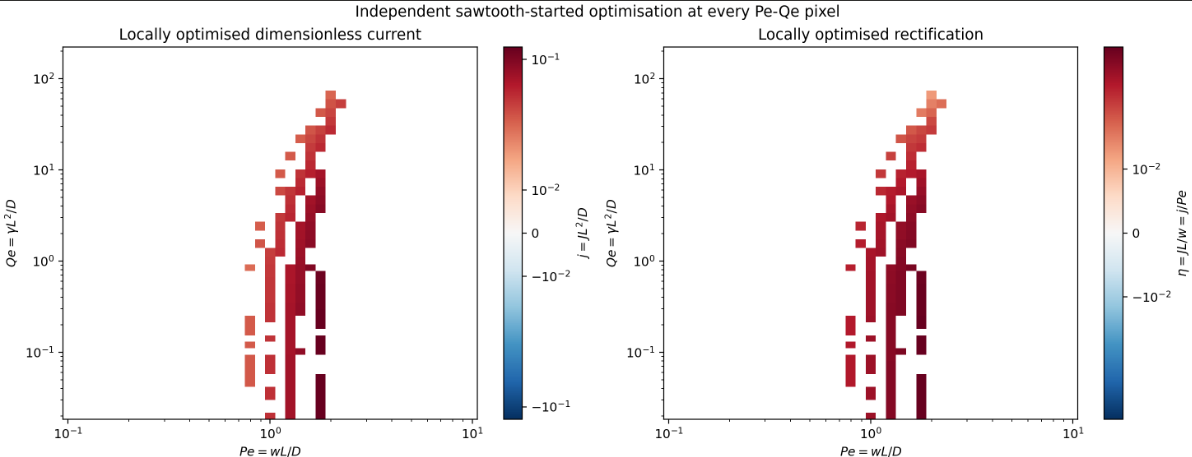

Objective now is to see how A varies on this heat map, and clear up numerical errors
STRATEGY: pick multiple points on this map, then evaluate surrounding currents quickly by initialising with optimum potential of a very slightly different (Pe, Qe) combination.
A = J_hat * L / w.